# Link Layer Guide

This notebook demonstrates the Link Layer features: entanglement requests, purification, fidelity tracking and resource accounting.

## Imports and Setup

In [2]:
import sys
sys.path.append('../')

from quantumnet.topology import Network, Host
from quantumnet.utils import Logger

Logger.get_instance().activate()

2026-02-22 19:31:27,729: Qubit 0 added to memory of Host 0.
2026-02-22 19:31:27,731: Qubit 0 created with initial fidelity 0.7304983764296538 and added to memory of Host 0.
2026-02-22 19:31:27,733: Qubit 1 added to memory of Host 0.
2026-02-22 19:31:27,736: Qubit 1 created with initial fidelity 0.6227468755187436 and added to memory of Host 0.
2026-02-22 19:31:27,737: Qubit 2 added to memory of Host 0.
2026-02-22 19:31:27,738: Qubit 2 created with initial fidelity 0.7673576070788007 and added to memory of Host 0.
2026-02-22 19:31:27,740: Qubit 3 added to memory of Host 0.
2026-02-22 19:31:27,742: Qubit 3 created with initial fidelity 0.5955418182774826 and added to memory of Host 0.
2026-02-22 19:31:27,743: Qubit 4 added to memory of Host 0.
2026-02-22 19:31:27,745: Qubit 4 created with initial fidelity 0.46693324015393245 and added to memory of Host 0.
2026-02-22 19:31:27,746: Qubit 5 added to memory of Host 0.
2026-02-22 19:31:27,747: Qubit 5 created with initial fidelity 0.226976449

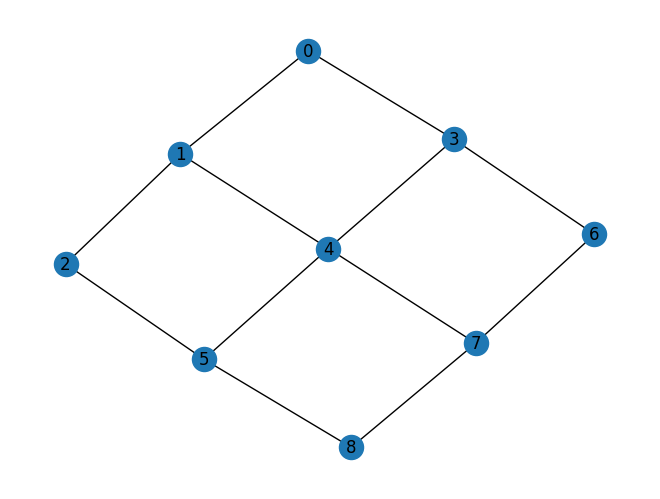

In [3]:
network = Network()
network.set_ready_topology("Grade", 3, 3)
network.draw()

## 1. Entanglement Request

`linklayer.request(alice_id, bob_id)` attempts to create entanglement between two adjacent hosts. It will:
1. Try the ECHP up to `config.protocol.link_max_attempts` times.
2. If fidelity is above the threshold, the entanglement succeeds.
3. After repeated failures, it automatically attempts **purification**.

In [4]:
result = network.linklayer.request(1, 2)
print(f"\nEntanglement request result: {result}")
print(f"Successful requests: {network.linklayer.requests}")
print(f"Failed requests: {network.linklayer.failed_requests}")

2026-02-22 19:31:28,901: Timeslot 0: Entanglement attempt between 1 and 2.
2026-02-22 19:31:28,903: Timeslot 1: EPR pair created with fidelity 0.04297994119508994
2026-02-22 19:31:28,904: Timeslot 1: Entanglement creation protocol succeeded, but with low fidelity.
2026-02-22 19:31:28,905: Timeslot 1: Entanglement failed between 1 and 2 on attempt 1.
2026-02-22 19:31:28,906: Timeslot 1: Entanglement attempt between 1 and 2.
2026-02-22 19:31:28,908: Timeslot 2: EPR pair created with fidelity 0.21965213334013334
2026-02-22 19:31:28,909: Timeslot 2: Entanglement creation protocol succeeded, but with low fidelity.
2026-02-22 19:31:28,910: Timeslot 2: Entanglement failed between 1 and 2 on attempt 2.
2026-02-22 19:31:28,911: Purification type 1 was used.
2026-02-22 19:31:28,911: Timeslot 3: Purification failed on channel (1, 2) due to low fidelity after purification.



Entanglement request result: False
Successful requests: []
Failed requests: [(1, 2), (1, 2)]


## 2. Average Fidelity on the Link Layer

Calculates the average fidelity of all EPR pairs created through the link layer.

In [5]:
avg_fid = network.linklayer.avg_fidelity_on_linklayer()
print(f"\nAverage link layer fidelity: {avg_fid:.6f}")

2026-02-22 19:31:28,926: Total EPRs created in the link layer: 2
2026-02-22 19:31:28,927: Total fidelity of EPRs created in the link layer: 0.23250067237414285
2026-02-22 19:31:28,929: The average fidelity of EPRs created in the link layer is 0.11625033618707142



Average link layer fidelity: 0.116250


## 3. Purification

Purification takes two low-fidelity EPR pairs and attempts to produce one with higher fidelity. There are three purification formulas:
1. **Type 1** — Default
2. **Type 2** — BBPSSW Protocol
3. **Type 3** — DEJMPS Protocol

Purification is called automatically after `link_purification_after_failures` failed attempts, but can also be invoked directly.

In [6]:
# The purification calculator can be used independently
f1, f2 = 0.7, 0.6
for ptype in [1, 2, 3]:
    result = network.linklayer.purification_calculator(f1, f2, ptype)
    print(f"Type {ptype}: purified fidelity = {result:.4f}")

2026-02-22 19:31:28,944: Purification type 1 was used.
2026-02-22 19:31:28,945: Purification type 2 was used.
2026-02-22 19:31:28,946: Purification type 3 was used.


Type 1: purified fidelity = 0.7778
Type 2: purified fidelity = 0.6771
Type 3: purified fidelity = 0.5567


## 4. Resource Usage

In [7]:
print(f"EPRs used (link layer): {network.linklayer.get_used_eprs()}")
print(f"Qubits used (link layer): {network.linklayer.get_used_qubits()}")
print(f"Current timeslot: {network.clock.now}")

2026-02-22 19:31:28,960: EPRs used in layer LinkLayer: 2
2026-02-22 19:31:28,961: Qubits used in layer LinkLayer: 4


EPRs used (link layer): 2
Qubits used (link layer): 4
Current timeslot: 3


## 5. Inspecting EPR Channels

In [8]:
eprs = network.get_eprs()
for edge, epr_list in eprs.items():
    print(f"Channel {edge}: {len(epr_list)} EPR pairs")

Channel (0, 3): 10 EPR pairs
Channel (0, 1): 10 EPR pairs
Channel (1, 4): 10 EPR pairs
Channel (1, 2): 12 EPR pairs
Channel (2, 5): 10 EPR pairs
Channel (3, 6): 10 EPR pairs
Channel (3, 4): 10 EPR pairs
Channel (4, 7): 10 EPR pairs
Channel (4, 5): 10 EPR pairs
Channel (5, 8): 10 EPR pairs
Channel (6, 7): 10 EPR pairs
Channel (7, 8): 10 EPR pairs


## 6. Global Resource Totals

In [9]:
print(f"Total used EPRs (all layers): {network.get_total_used_eprs()}")
print(f"Total used qubits (all layers): {network.get_total_used_qubits()}")

2026-02-22 19:31:28,985: EPRs used in layer PhysicalLayer: 2
2026-02-22 19:31:28,988: EPRs used in layer LinkLayer: 2
2026-02-22 19:31:28,988: EPRs used in layer NetworkLayer: 0
2026-02-22 19:31:28,989: Qubits used in layer PhysicalLayer: 4
2026-02-22 19:31:28,990: Qubits used in layer LinkLayer: 4
2026-02-22 19:31:28,991: Qubits used in layer TransportLayer: 0
2026-02-22 19:31:28,991: Qubits used in layer ApplicationLayer: 0


Total used EPRs (all layers): 4
Total used qubits (all layers): 8


## 7. Qubit Creation Timeslots

In [10]:
network.display_all_qubit_timeslots()

2026-02-22 19:31:29,002: Qubit 0 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:31:29,003: Qubit 1 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:31:29,003: Qubit 2 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:31:29,004: Qubit 3 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:31:29,005: Qubit 4 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:31:29,006: Qubit 5 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:31:29,007: Qubit 6 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:31:29,008: Qubit 7 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:31:29,008: Qubit 8 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:31:29,010: Qubit 9 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:31:29,010: Qubit 10 was created at timeslot 0 in layer Physical Layer
2026-02-22 19:31:29,011: Qubit 11 was created at timeslot 0 in layer Physical Layer
20